<a href="https://colab.research.google.com/github/Saurabh312Kumar/ML-Concepts/blob/main/knn_breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV

In [2]:
data_set=load_breast_cancer()
print(data_set.target_names)
print(data_set.feature_names)

['malignant' 'benign']
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [3]:
X=data_set.data
y=data_set.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, test_size=0.3, random_state=42)

In [5]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [6]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)
y_pred=knn_model.predict(X_test_scaled)

In [7]:
conf_mat=confusion_matrix(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
eval_report=classification_report(y_test,y_pred)

In [8]:
print(conf_mat)
print(accuracy)
print(eval_report)

[[ 57   7]
 [  0 107]]
0.9590643274853801
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        64
           1       0.94      1.00      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



In [9]:
k=range(1,20,2)
accuracies=[]
for i in k:
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train_scaled,y_train)
  y_pred=knn.predict(X_test_scaled)

  accuracy=accuracy_score(y_test,y_pred)
  accuracies.append(accuracy)
  print(f"K = {i}, Accuracy = {accuracy:.4f}")

K = 1, Accuracy = 0.9591
K = 3, Accuracy = 0.9532
K = 5, Accuracy = 0.9591
K = 7, Accuracy = 0.9649
K = 9, Accuracy = 0.9649
K = 11, Accuracy = 0.9649
K = 13, Accuracy = 0.9591
K = 15, Accuracy = 0.9591
K = 17, Accuracy = 0.9532
K = 19, Accuracy = 0.9474


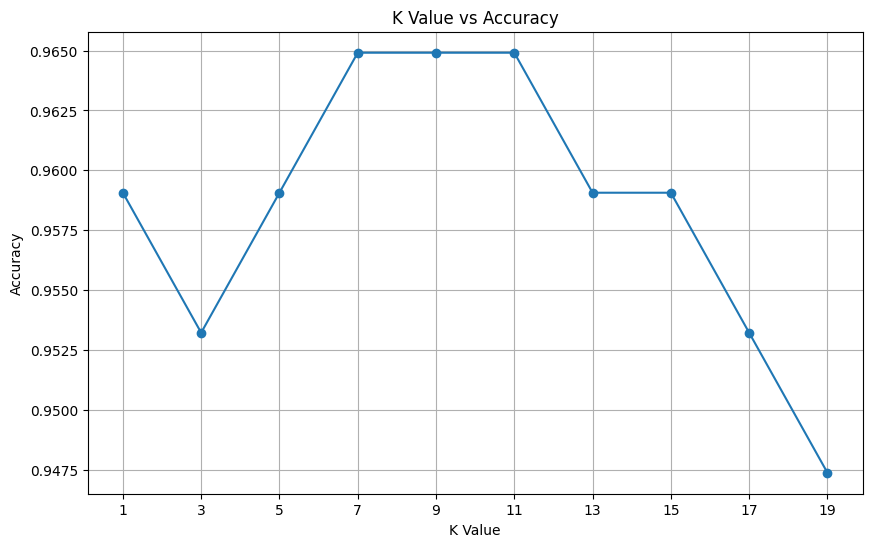

In [10]:
plt.figure(figsize=(10,6))

plt.plot(k,accuracies,marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")

plt.xticks(k)
plt.grid()

plt.show()